In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
#connecting to google drive to load content
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#path to fetch dataset
path='/content/drive/MyDrive/survey_lung_cancer.csv'
df=pd.read_csv(path)
df

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [ ]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [ ]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.shape

(276, 16)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['LUNG_CANCER']=encoder.fit_transform(df['LUNG_CANCER'])
df['GENDER']=encoder.fit_transform(df['GENDER'])
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


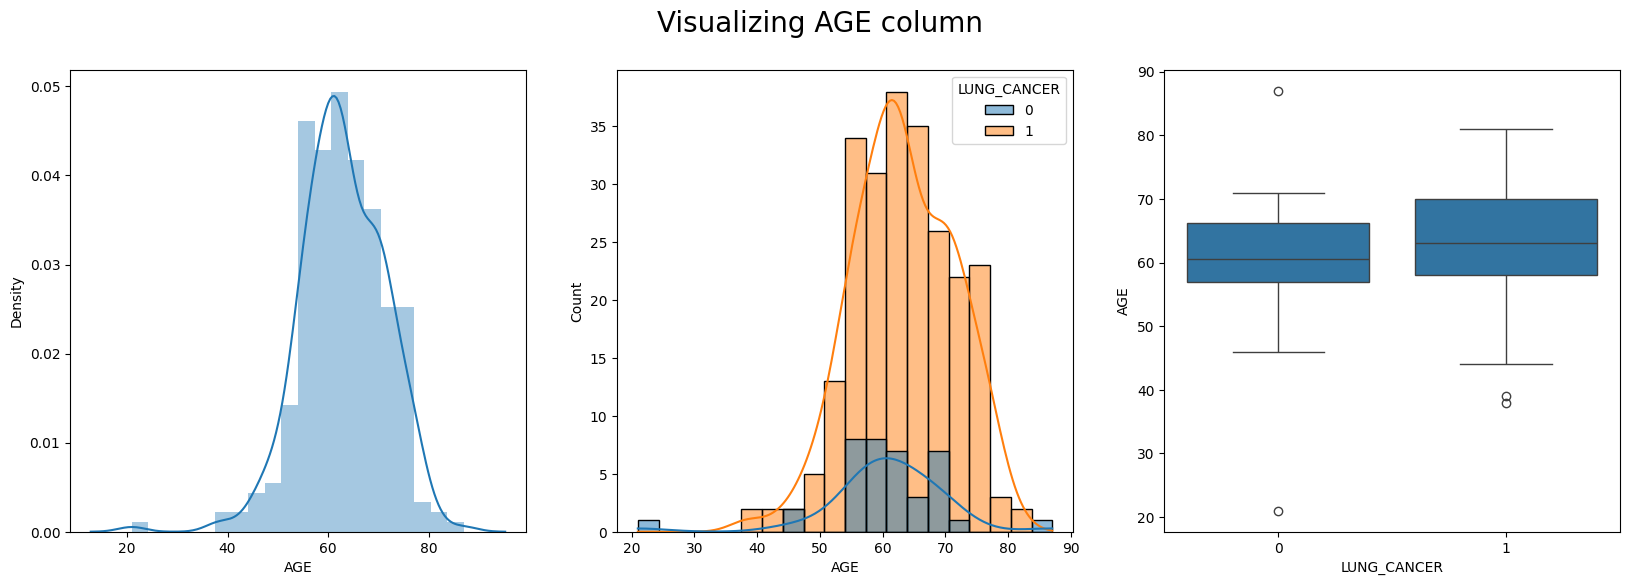

In [ ]:
#separating continuous and categorical columns so that it can be in binary format
con_col = ['AGE']
cat_col=[]
for i in df.columns:
    if i!='AGE':
        cat_col.append(i)
import warnings
warnings.filterwarnings('ignore')
fig,ax = plt.subplots(1,3,figsize=(20,6))
sns.distplot(df['AGE'],ax=ax[0])
sns.histplot(data =df,x='AGE',ax=ax[1],hue='LUNG_CANCER',kde=True)
sns.boxplot(x=df['LUNG_CANCER'],y=df['AGE'],ax=ax[2])
plt.suptitle("Visualizing AGE column",size=20)
plt.show()

<Axes: >

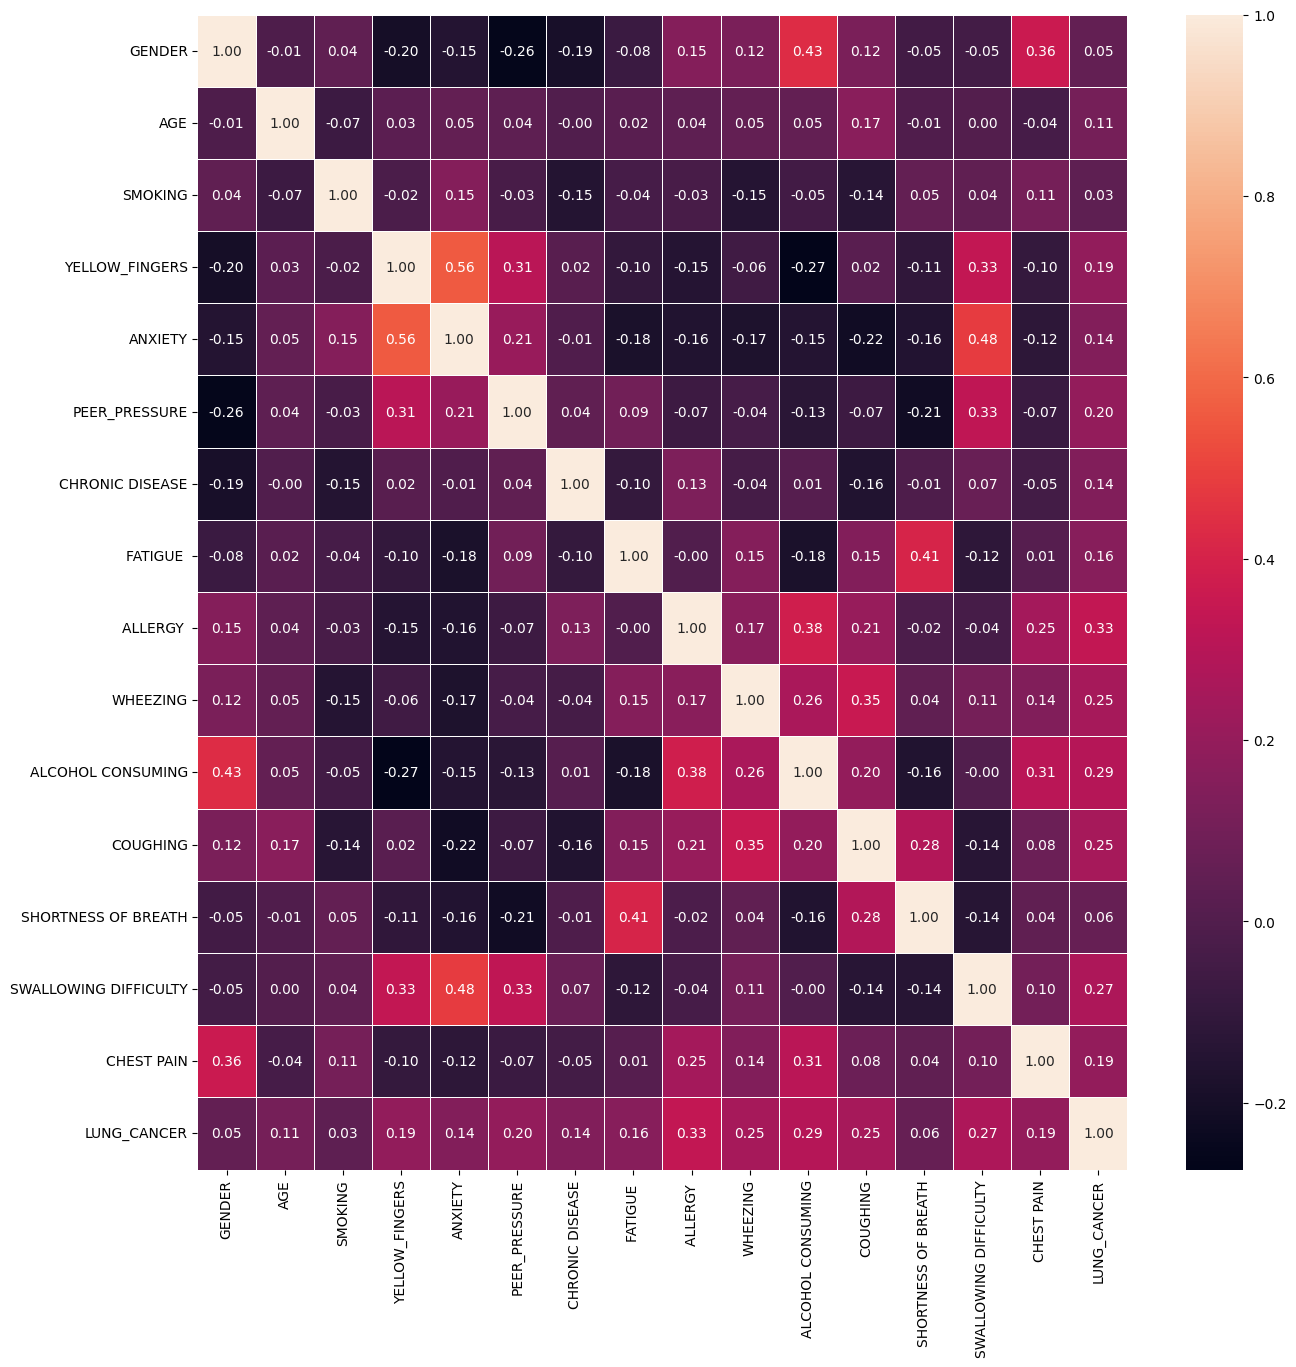

In [ ]:
#display data graphically
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True,linewidth=0.5,fmt='0.2f')

In [ ]:
#drop the last column displaying lung cancer yes or no and displaing all other columns
x=df.drop(['LUNG_CANCER'],axis=1)
y=df['LUNG_CANCER']
for i in x.columns[2:]:
    temp=[]
    for j in x[i]:
        temp.append(j-1)
    x[i]=temp
x.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0


In [ ]:
from imblearn.over_sampling import RandomOverSampler
x_over,y_over=RandomOverSampler().fit_resample(x,y)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_over,y_over,random_state=42,stratify=y_over)
print(f'Train shape : {x_train.shape}\nTest shape: {x_test.shape}')

Train shape : (357, 15)
Test shape: (119, 15)


In [ ]:
#scaling the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# **1. SVM Classifier**

In [ ]:
#training the data in svm model
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(x_train_scaled, y_train)
#testing of the data
svm_pred = svm_model.predict(x_test_scaled)
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#accuracy score
accuracy = accuracy_score(y_test, svm_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
#classification report
print("Classification Report:")
print(classification_report(y_test, svm_pred))

Accuracy: 89.92%
Confusion Matrix:
[[57  3]
 [ 9 50]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        60
           1       0.94      0.85      0.89        59

    accuracy                           0.90       119
   macro avg       0.90      0.90      0.90       119
weighted avg       0.90      0.90      0.90       119



# **2. Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_reg = LogisticRegression()
logistic_reg.fit(x_train_scaled, y_train)
#testing of the data
logisticregression_pred = logistic_reg.predict(x_test_scaled)
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#accuracy score
accuracy = accuracy_score(y_test, logisticregression_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, logisticregression_pred))
#classification report
print("Classification Report:")
print(classification_report(y_test, logisticregression_pred))

Accuracy: 85.71%
Confusion Matrix:
[[52  8]
 [ 9 50]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        60
           1       0.86      0.85      0.85        59

    accuracy                           0.86       119
   macro avg       0.86      0.86      0.86       119
weighted avg       0.86      0.86      0.86       119



# **3.Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_clf = DecisionTreeClassifier()
decision_tree_clf.fit(x_train_scaled, y_train)
#testing of the data
decisiontree_pred = decision_tree_clf.predict(x_test_scaled)
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#accuracy score
accuracy = accuracy_score(y_test, decisiontree_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, decisiontree_pred))
#classification report
print("Classification Report:")
print(classification_report(y_test, decisiontree_pred))

Accuracy: 93.28%
Confusion Matrix:
[[56  4]
 [ 4 55]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        60
           1       0.93      0.93      0.93        59

    accuracy                           0.93       119
   macro avg       0.93      0.93      0.93       119
weighted avg       0.93      0.93      0.93       119



# **4.Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest_clf = RandomForestClassifier()
random_forest_clf.fit(x_train_scaled, y_train)
#testing of the data
randomclassifier_pred = random_forest_clf.predict(x_test_scaled)
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#accuracy score
accuracy = accuracy_score(y_test, randomclassifier_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, randomclassifier_pred))
#classification report
print("Classification Report:")
print(classification_report(y_test, randomclassifier_pred))

Accuracy: 94.96%
Confusion Matrix:
[[60  0]
 [ 6 53]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        60
           1       1.00      0.90      0.95        59

    accuracy                           0.95       119
   macro avg       0.95      0.95      0.95       119
weighted avg       0.95      0.95      0.95       119



# **5. KNN model**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train_scaled, y_train)
#testing of the data
knn_pred = knn_clf.predict(x_test_scaled)
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#accuracy score
accuracy = accuracy_score(y_test, knn_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))
#classification report
print("Classification Report:")
print(classification_report(y_test, knn_pred))

Accuracy: 89.92%
Confusion Matrix:
[[60  0]
 [12 47]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        60
           1       1.00      0.80      0.89        59

    accuracy                           0.90       119
   macro avg       0.92      0.90      0.90       119
weighted avg       0.92      0.90      0.90       119



# **6.Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB
naivebayes_clf = KNeighborsClassifier()
naivebayes_clf.fit(x_train_scaled, y_train)
#testing of the data
naivebayes_pred = naivebayes_clf.predict(x_test_scaled)
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#accuracy score
accuracy = accuracy_score(y_test, naivebayes_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, naivebayes_pred))
#classification report
print("Classification Report:")
print(classification_report(y_test, naivebayes_pred))

Accuracy: 89.92%
Confusion Matrix:
[[60  0]
 [12 47]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        60
           1       1.00      0.80      0.89        59

    accuracy                           0.90       119
   macro avg       0.92      0.90      0.90       119
weighted avg       0.92      0.90      0.90       119



# **7.XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier
xgboost_clf = KNeighborsClassifier()
xgboost_clf.fit(x_train_scaled, y_train)
#testing of the data
xgboost_pred = xgboost_clf.predict(x_test_scaled)
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#accuracy score
accuracy = accuracy_score(y_test, xgboost_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgboost_pred))
#classification report
print("Classification Report:")
print(classification_report(y_test, xgboost_pred))

Accuracy: 89.92%
Confusion Matrix:
[[60  0]
 [12 47]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        60
           1       1.00      0.80      0.89        59

    accuracy                           0.90       119
   macro avg       0.92      0.90      0.90       119
weighted avg       0.92      0.90      0.90       119



# **Comparison of the models**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# Function to calculate and return metrics as a list
def get_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return [accuracy, precision, recall, f1]
# Calculate metrics for each model
svm_metrics = get_metrics(y_test, svm_pred)
knn_metrics = get_metrics(y_test, knn_pred)
logisticregression_metrics = get_metrics(y_test, logisticregression_pred)
naivebayes_metrics = get_metrics(y_test, naivebayes_pred)
decisiontree_metrics = get_metrics(y_test, decisiontree_pred)
randomclassifier_metrics = get_metrics(y_test, randomclassifier_pred)
xgboost_metrics = get_metrics(y_test, xgboost_pred)

# Create the DataFrame
Model_Comparison_Table = pd.DataFrame(data = [svm_metrics,
                                              knn_metrics,
                                              logisticregression_metrics,
                                              naivebayes_metrics,
                                              decisiontree_metrics,
                                              randomclassifier_metrics,
                                              xgboost_metrics],
                                      index = ['SVM','KNN','Logistic Regression','Naive Bayes','Decision Tree','Random Forest','XGBoost'],
                                      columns = ['Accuracy %','Precision','Recall','F1 Score'])

# Convert accuracy to percentages and round to 2 decimal places
Model_Comparison_Table['Accuracy %'] = (Model_Comparison_Table['Accuracy %'] * 100).round(2)

# Sort the DataFrame by accuracy
Model_Comparison_Table.sort_values(by = 'Accuracy %', ascending = False)

,Accuracy %,Precision,Recall,F1 Score
Random Forest,94.96,1.000000,0.898305,0.946429
Decision Tree,93.28,0.932203,0.932203,0.932203
SVM,89.92,0.943396,0.847458,0.892857
KNN,89.92,1.000000,0.796610,0.886792
Naive Bayes,89.92,1.000000,0.796610,0.886792
XGBoost,89.92,1.000000,0.796610,0.886792
Logistic Regression,85.71,0.862069,0.847458,0.854701


In [ ]:
#export the model as its ready now
import joblib
# Save the model
joblib.dump(svm_model, 'modellungcancer.pkl')

['modellungcancer.pkl']